<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/Kreditscoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Aufgabe zur Logistischen Regression

## Kreditscoring-Datensatz

Der Datensatz *Kreditscoring zur Klassifikation von Kreditnehmern. 2010. Open Data LMU.* ([https://doi.org/10.5282/ubm/data.23](https://doi.org/10.5282/ubm/data.23)) beinhaltet 1000 Datensätze, die Vergaben von Privatkrediten durch eine süddeutsche Großbank dokumentieren. Die Daten wurden ursprünglich für Forschung und Lehre bereitgestellt und bieten eine realitätsnahe Grundlage für Klassifikationsaufgaben im Bereich Kreditrisiko.

Die Spalten beschreiben verschiedene Merkmale, die sich drei übergeordneten Bereichen zuordnen lassen:

- die **persönliche Situation** der Kreditnehmer (z. B. Alter, Familienstand),
- die **wirtschaftliche Situation** (z. B. Einkommen, Höhe und Laufzeit des Darlehens, vorhandene Sicherheiten),
- die **rechtliche Stellung** (z. B. Art der Beschäftigung, laufende Verpflichtungen, Anzahl der bestehenden Kredite).

Beispiele für enthaltene Variablen:
- `laufzeit` – Laufzeit des beantragten Kredits (Monate),
- `hoehe` – Höhe des beantragten Kredits,
- `sparkont` – Kategorie des Sparguthabens (ordinal),
- `beszeit` – Beschäftigungsdauer in Jahren (ordinal),
- `rate` – Rückzahlungsrate bezogen auf Einkommen (prozentual),
- `famges` – Familienstand und Anzahl unterhaltsberechtigter Personen,
- `wohnzeit` – Dauer des aktuellen Wohnsitzes (Jahre),
- `buerge` – Bürgschaftsverhältnis (z. B. allein, Mitunterzeichner),
- `verm` – Vermögensverhältnisse (z. B. Immobilie, Lebensversicherung),
- `alter` – Alter der Antragsteller.

Die **Zielgröße** (auch *Target Variable* genannt) ist die Spalte `kredit`. Sie ist binär kodiert:
- `1` bedeutet, dass der entsprechende Kredit **ordnungsgemäß zurückgezahlt** wurde,
- `0` bedeutet, dass der Kredit **nicht vollständig oder gar nicht zurückgezahlt** wurde (Ausfall).

### Zielsetzung

Ziel des maschinellen Lernens in diesem Szenario ist es, ein System zu entwickeln, das für eine neue, potenzielle Kreditvergabe möglichst zuverlässig vorhersagen kann, ob der beantragte Kredit mit hoher Wahrscheinlichkeit zurückgezahlt werden wird oder nicht. Die Entscheidung stützt sich dabei auf Muster, die aus den vorhandenen historischen Daten gelernt werden.

Dieses Verfahren ist unter dem Begriff **Kreditscoring** bekannt. Es ist in der Praxis weit verbreitet und stellt ein zentrales Element in der Risikobewertung und Entscheidungsfindung von Banken und anderen Kreditinstituten dar. Statistische Modelle und maschinelle Lernverfahren helfen dabei, objektive, datengestützte Entscheidungen zu treffen und Kreditrisiken zu minimieren.

Mehr Informationen und eine vollständige Beschreibung aller Merkmale finden sich unter:  
[https://data.ub.uni-muenchen.de/23/1/DETAILS.html](https://data.ub.uni-muenchen.de/23/1/DETAILS.html)



---


Die Zielgröße: kredit
Das ist die entscheidende Spalte – sie ist binär kodiert:

1 → Kredit wurde ordnungsgemäß zurückgezahlt ("guter" Kunde)
0 → Kredit wurde nicht oder nicht vollständig zurückgezahlt ("Ausfall")

Der Fachbegriff: Kreditscoring

Das beschriebene Verfahren heißt in der Praxis Credit Scoring. Jeder Antragsteller bekommt dabei einen Score – eine Zahl, die die Kreditwürdigkeit ausdrückt. Bekannte Beispiele aus dem Alltag:

SCHUFA-Score in Deutschland
FICO-Score in den USA

---



Wir importieren zuerst die Pandas Bibliothek und laden den Datensatz `kredit.csv` in einen `DataFrame`.

In [1]:
import pandas as pd
import os
import urllib.request

url = "https://github.com/fhswf/datasets/raw/main/kredit.csv"
dfile = "./kredit.csv"

if not os.path.isfile(dfile):
    urllib.request.urlretrieve(url, dfile)

In [2]:
import pandas as pd
df = pd.read_csv("kredit.csv")
df.head(10)

,kredit,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,...,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2
5,1,1,10,4,0,2241,1,2,1,3,...,3,1,48,3,1,2,2,2,1,2
6,1,1,8,4,0,3398,1,4,1,3,...,4,1,39,3,2,2,2,1,1,2
7,1,1,6,4,0,1361,1,2,2,3,...,4,1,40,3,2,1,2,2,1,2
8,1,4,18,4,3,1098,1,1,4,2,...,4,3,65,3,2,2,1,1,1,1
9,1,2,24,2,3,3758,3,1,1,2,...,4,4,23,3,1,1,1,1,1,1


Mit `df.info()` und `df.describe()` erhalten wir einige Informationen über den Datensatz.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   kredit    1000 non-null   int64
 1   laufkont  1000 non-null   int64
 2   laufzeit  1000 non-null   int64
 3   moral     1000 non-null   int64
 4   verw      1000 non-null   int64
 5   hoehe     1000 non-null   int64
 6   sparkont  1000 non-null   int64
 7   beszeit   1000 non-null   int64
 8   rate      1000 non-null   int64
 9   famges    1000 non-null   int64
 10  buerge    1000 non-null   int64
 11  wohnzeit  1000 non-null   int64
 12  verm      1000 non-null   int64
 13  alter     1000 non-null   int64
 14  weitkred  1000 non-null   int64
 15  wohn      1000 non-null   int64
 16  bishkred  1000 non-null   int64
 17  beruf     1000 non-null   int64
 18  pers      1000 non-null   int64
 19  telef     1000 non-null   int64
 20  gastarb   1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


In [4]:
df.describe()

,kredit,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,...,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


Wir teilen nun die kompletten Daten in einen Trainings- und einen Test-Datensatz auf.
Dazu kann die Methode `train_test_split()` aus dem Modul `sklearn.model_selection` verwendet werden.
Der Parameter `test_size` legt den Anteil des Daten im Test-Datensatz fest.
Die Aufteilung der Datenpunkte erfolgt zufällig.
Falls Sie immer die gleiche Aufteilung vornehmen wollen (damit die Ergebnisse vergleichbar sind) können Sie durch Festlegen des Parameters `random_state` erzwingen, dass immer die gleichen Folgen von Zufallszahlen erzeugt werden.



---
Warum überhaupt aufteilen?
Bevor wir in den Code gehen, die wichtigste Frage: Wozu das Ganze?
Wenn man ein Modell auf allen 1.000 Datensätzen trainiert und es dann auf denselben Daten testet, ist das wie eine Klausur mit den Lösungen vorher. Das Modell könnte einfach auswendig lernen und sähe perfekt aus – würde aber bei einem neuen, unbekannten Kunden völlig versagen. Dieses Problem heißt Overfitting.


---




In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.3, random_state=0) #Mach 30 % davon zu Testdaten." Die anderen 70 % sind automatisch Trainingsdaten.

df.iloc[:,0]  : Gib mir die Spalte ganz links" (Spalte Nummer 0 = die kredit-Spalte).

df.iloc[:,1:] : Gib mir alle Spalten ab Spalte 1" (also alles AUSSER der kredit-Spalte).

In [6]:
df.corr().kredit.abs().sort_values()

,kredit
wohnzeit,0.002967
pers,0.003015
verw,0.017979
wohn,0.018119
buerge,0.025137
beruf,0.032735
telef,0.036466
bishkred,0.045732
rate,0.072404
gastarb,0.082079




---
1. df.corr() – Korrelationen berechnen
Erstellt eine Korrelationsmatrix: Für jedes Paar von Spalten wird berechnet, wie stark sie zusammenhängen. Das Ergebnis ist eine 21×21-Tabelle mit Werten zwischen –1 und +1

2. .kredit – Nur die Spalte kredit herausgreifen
Aus der riesigen Matrix interessiert uns nur eine Spalte: Wie korreliert jedes Merkmal mit der Zielvariable kredit?

3. .abs() – Absolutbetrag bilden
Ob ein Zusammenhang positiv (+0.3) oder negativ (–0.3) ist, ist für die Stärke egal. Beide sind gleich aussagekräftig. Mit abs() machen wir alle Werte positiv

je höher ,desto höher der einfluss

---



Wenn Sie testen wollen, wie gut das Modell mit einer Auswahl der Merkmale funktioniert, können Sie die Spalten im Datensatz entsprechend einschränken.

In [7]:
from sklearn.model_selection import train_test_split
features = ["sparkont","rate"] #Jetzt nehmen wir nur zwei bestimmte Spalten
X_train, X_test, y_train, y_test = train_test_split(df[features],df.iloc[:,0],test_size=0.3, random_state=0) #df.iloc[:,0] → weiterhin die Zielspalte kredit / df.iloc[ZEILEN , SPALTEN]

**Hinweis:** Wie bereits in früheren Praktika behandelt, ist es bei vielen Modellen wichtig, die Eingabedaten auf eine einheitliche Skala zu bringen.

Die logistische Regression ist empfindlich gegenüber unterschiedlich skalierten Features. Wir verwenden daher `StandardScaler`, um die numerischen Merkmale auf Mittelwert 0 und Standardabweichung 1 zu normieren.


---
Die Zahlen in hoehe sind hunderte Male größer als in alter. Manche Modelle (wie die logistische Regression) "denken" dann: "Die hoehe ist viel wichtiger, weil die Zahlen so groß sind!" – auch wenn das in Wirklichkeit gar nicht stimmt.

Er rechnet jede Spalte so um, dass sie danach:

Mittelwert = 0 hat

Standardabweichung = 1 hat


---




In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # Lösung: Alle Spalten auf eine einheitliche Skala bringen.
X_train = scaler.fit_transform(X_train) #fit = "Lerne": Der Scaler misst Mittelwert und Standardabweichung jeder Spalte in X_train und merkt sie sich.
X_test = scaler.transform(X_test) #Der Scaler benutzt die gleichen Mittelwerte und Standardabweichungen, die er sich von den Trainingsdaten gemerkt hat, und wendet sie auf die Testdaten an.

Für die Modellbildung verwenden wir nun wieder `sklearn`, diesmal mit einem logistischen Regressionsmodell.

Die Modellparameter können über die Attribute `intercept_` und `coef_` abgerufen werden.
Üblicherweise interessieren den Programmierer diese Werte nicht.
die Schätzung für einen neuen Datenpunkt kann ja ganz einfach mit der Funktion `predict()` berechnet werden.
Für uns sind die Informationen allerdings interessant, wenn wir die Methode `fit()` händisch nachprogrammieren wollen und so die jeweiligen gelerneten Modellparameter miteinander vergleichen können.

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() #Erzeugt ein leeres Modell.
model.fit(X_train,y_train) #X_train = die Merkmale der Trainingskunden (sparkont, rate) / y_train = die richtigen Antworten (kredit zurückgezahlt? 0 oder 1)

model.intercept_,  model.coef_[0] #Zeigt die gelernten Parameter an. Das Ergebnis:

(array([0.96866116]), array([ 0.41347165, -0.2661684 ]))

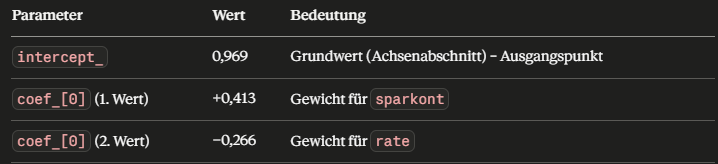

Positiv (+0,413) bei sparkont: Je höher das Sparkonto, desto wahrscheinlicher wird der Kredit zurückgezahlt. → Macht Sinn: Wer Geld auf dem Sparbuch hat, ist solventer.
Negativ (−0,266) bei rate: Je höher die Rate, desto unwahrscheinlicher wird der Kredit zurückgezahlt. → Macht auch Sinn: Hohe Raten sind schwerer zu bezahlen.

Nachdem Wir das Modell mit den Trainingsdaten trainiert haben, verwenden wir den Testdatensatz um die Qualität des Modells zu bewerten.
Eine Vorhersagegenauigkeit von 66,6% bedeutet, dass für 2 von 3 Krediten korrekt vorhergesagt werden konnte, ob ein Kredit vom Bankkunden ordnungsgemäß zurückgezahlt wurde.

In [10]:
import numpy as np
y_pred = model.predict(X_test) #wir geben das gelernte modell unsere testdaten
acc_train = np.sum((y_pred==y_test)*1)/len(y_test) # Y_Test sind die echten antworten
print("Accuracy (Testdaten): %.2f%%" % (acc_train*100))

Accuracy (Testdaten): 66.67%


**Aufgabe:** **Verwenden nun alle Merkmale des Datensatzes in einem neuen Modell und berechnen Sie die *Classification Accuracy* für dieses Modell.**

In [11]:

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.3, random_state=0)

scaler = StandardScaler() # Lösung: Alle Spalten auf eine einheitliche Skala bringen.
X_train = scaler.fit_transform(X_train) #fit = "Lerne": Der Scaler misst Mittelwert und Standardabweichung jeder Spalte in X_train und merkt sie sich.
X_test = scaler.transform(X_test) #Der Scaler benutzt die gleichen Mittelwerte und Standardabweichungen, die er sich von den Trainingsdaten gemerkt hat, und wendet sie auf die Testdaten an.

model = LogisticRegression() #Erzeugt ein leeres Modell.
model.fit(X_train,y_train) #X_train = die Merkmale der Trainingskunden (sparkont, rate) / y_train = die richtigen Antworten (kredit zurückgezahlt? 0 oder 1)

y_pred = model.predict(X_test) #wir geben das gelernte modell unsere testdaten
acc_train = np.sum((y_pred==y_test)*1)/len(y_test) # Y_Test sind die echten antworten
print("Accuracy (Testdaten): %.2f%%" % (acc_train*100))


Accuracy (Testdaten): 75.33%


**Einordnung der Accuracy**

Das Modell erreicht auf den Testdaten eine Accuracy von ca. **75%**. Das bedeutet, dass etwa drei von vier Kreditentscheidungen korrekt vorhergesagt wurden – also ob ein Kredit zurückgezahlt wird (`kredit=1`) oder nicht (`kredit=0`).

**Ist das gut?**

Das hängt vom Anwendungsfall ab:

- In vielen klassischen Klassifikationsaufgaben (z. B. Bilderkennung) wäre eine Accuracy von 75 % eher mittelmäßig.
- Im **Kreditscoring** ist die Situation jedoch komplexer: Eine *falsche Entscheidung* kann entweder bedeuten, dass
  - **ein sicherer Kredit abgelehnt wird** (*false negative*) oder
  - **ein riskanter Kredit vergeben wird** (*false positive*).

Je nach Geschäftspriorität (z. B. Ausfallsvermeidung vs. Umsatzsteigerung) sind unterschiedliche Fehlertypen unterschiedlich kritisch. Daher ist die **reine Accuracy nicht ausreichend**, um ein Modell abschließend zu bewerten.

**Was fehlt?**

Für eine fundierte Bewertung benötigen wir zusätzliche Metriken wie:
- **Precision**: Wie zuverlässig sind die als „Zahlungsfähig“ klassifizierten Fälle?
- **Recall**: Wie viele der tatsächlichen Rückzahler hat das Modell erkannt?
- **F1-Score**: Kombination aus Precision und Recall.
- **Konfusionsmatrix**: Zeigt, welche Fehlertypen das Modell macht.

Diese Metriken werden wir in einem späteren Praktikum noch ausführlich behandeln.

**Fazit:**
Eine Accuracy von über 75 % ist ein **guter Startpunkt** für ein erstes Modell im Kreditbereich. In der Praxis würde man nun weiter analysieren, **wie sich das Modell verhält**, **welche Merkmale wichtig sind**, und wie man **Risiken und Chancen** balancieren kann.



---



Accuracy ist ein Anfang, keine Antwort.

Du hast erfolgreich ein Modell trainiert, das besser ist als blindes Raten. Aber in einer echten Bank würde man jetzt fragen:

Was kostet ein falsch vergebener Kredit?

Was kostet ein abgelehnter guter Kunde?

Wo will die Bank den Schwerpunkt setzen – Sicherheit (weniger Ausfälle) oder Umsatz (mehr Kunden bedienen)?



---



In [12]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 